<a href="https://colab.research.google.com/github/bcramp/ML/blob/main/HW2/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

HW 2

Title: Assignment Analysis

Name: Brennen Cramp

Date: 9/12/2026

---

# Analysis
---

1. There were no challenges encountered when loading the raw external CSV file from Kaggle compared to pre-packaged datasets. However, when it came to inspecting a real-world example from Kaggle versus pre-packaged datasets, I noticed there were null fields in the real-world dataset when pre-packaged datasets usually have every field and value covered. This caused issues in that I would need to impute the Kaggle dataset to fill those values which could mess with the reliability due to the manufactured nature of the process. Also, when inspecting the data, I found that underneath categorical features (i.e. browser_type) there were 'Unknown' values which can theoretically count as null values which can also hurt the reliability of the data.

2. I determined which column required missing value imputations by using "df.isnull().sum()" (in Step 4.1) from the Pandas library which helped count the missing values within the CSV file for numerical features and "df['cat_feature_name'].value_counts()" for categorical features. In particular, for the categorical features, this helped me figure out there were 502 counts of 'Unknown' values in the browser_type column, which can indicate missing or unrecorded metadata, but when verifying with Kaggle's column descriptions and value types, this value was added to "be an indicator of automated scripts or bots." However, for this experiment, I wanted to impute this data. In relation to which imputation strategies chosen, using Scikit-Learn's SimpleImputer to ensure consistency, I chose to first convert "Unknown" string values in browser_type to standard null blocks so the preprocessing tools could recognize them. Then, for text/categorical features (encryption_used and browser_type), missing entries were filled using the 'most_frequent' (mode / most occurring) strategy. This helped fill the gaps with the most common operational classes (values like 'Chrome' and 'AES') without inventing any new or arbitrary categories. For numerical features, the pipeline was structured to use a 'median' strategy. I preferred to use the median over the mean for network data because packet sizes and session lengths are typically heavily skewed and contain extreme outliers, which would artificially distort an average.

3. Scikit-Learn's ColumnTransformer and Pipeline streamline the data preparation process by providing a simultaneous and unified execution since ColumnTransformer automates the manual steps of applying separate transformations (StandardScaler and OneHotEncoder) and combining the dataframes back together. This structured approach also allows for high reproduction. This means it is highly streamlined since the same preparation steps can be quickly applied to any new testing data or future production data without rewriting the logic. It can also prevent data leakage since leakage happens when information from the validation or testing data "infects" the training process, leading to false accuracy scores. Scikit-Learn's Pipeline stops this by isolating the training data. Using the .fit_transform() functionality, the .fit() calculations like the 'median' for scaling or the 'most_frequent' category for encoding are calculated only on the training set while the "unseen" testing data is never fitted. The pipeline then applies the stored training parameters with the second step in the .fit_transform() function, the .transform() command. This guarantees that the evaluation data remains unchanged, providing a reliable measurement of how the model will perform on real-world data; thus preventing data leakage during the preprocessing steps.

4. Based on my correlation matrix/heatmap (*seen below under "Correlation Matrix/Heatmap - Step 6.1"*), the features that show the strongest relationships with the target variable are failed_logins with a positive correlation coefficient of 0.36, login_attempts with a positive correlation coefficient of 0.28, and ip_reputation_score with a positive correlation coefficient of 0.21. The corresponding scatter plot under *"Scatter Plot with Positive Correlation - Step 6.3 - Part 2"* demonstrates a clear grouping between attacks being detected (higher login attempts and higher failed logins) versus when attacks were not detected (low login attempts and low failed logins), which aligns with the data from the heatmap. Conversely, features that tracked traffic volume (network_packet_size = -0.01) and duration (session_duration = 0.04) display nonexistent linear correlation with the target variable, which can be viewed in the massive overlap within the produced scatter plot seen under *"Scatter Plot with Negative Correlation - Step 6.3 - Part 1"*. These relationships reveal operational insights into the nature of the network intrusions within this dataset. The prominent correlations for failed_logins and login_attempts indicate that the detected attacks are heavily driven by attackers failing authentication procedures while trying to access accounts. From being in the workforce over the past 4 years, I have learned that this is highly characteristic of brute-force attacks or possible automated credential-stuffing where malicious actors repeatedly attempt to access accounts. In relation to the positive correlation with ip_reputation_score, it continues to suggest that these authentication floods are constantly originating from known "bad" IP-addresses. Operationally, if I was part of a security team, this means I should push for automated defense mechanisms focused on identity and access management. Examples could be implementing strict rate-limiting, triggering account lockouts, and multi-factor authentication, as well as setting up proactive firewall blocks based on real-time threat intelligence feeds to stop known bad IPs before they can spam login endpoints.

# **Correlation Matrix/Heatmap - Step 6.1**

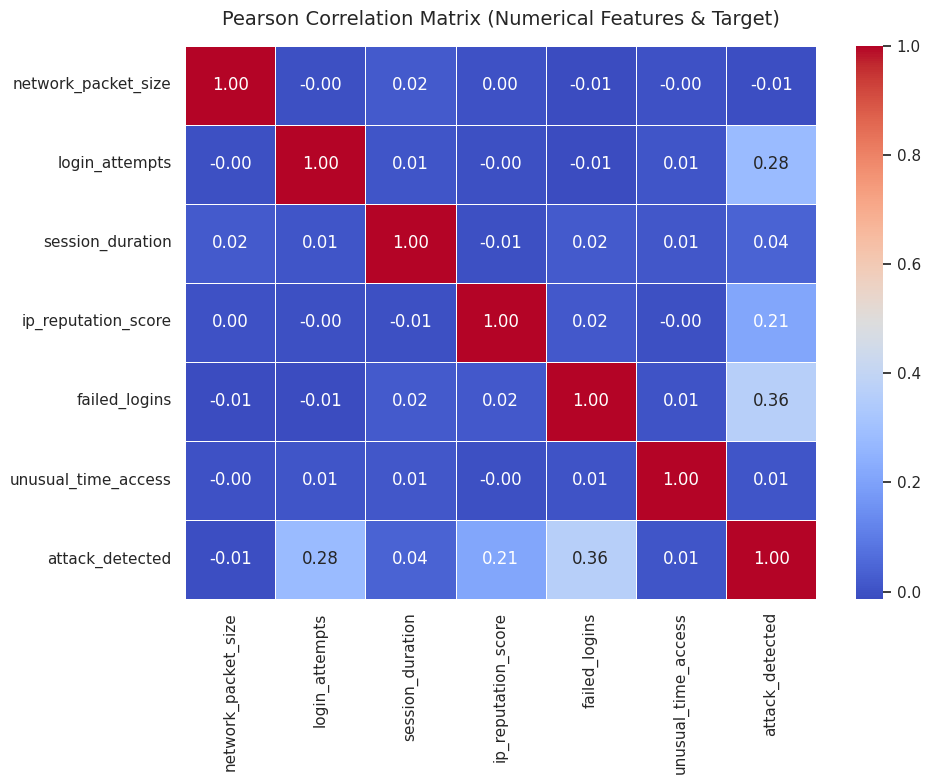

# **Scatter Plot with Negative Correlation - Step 6.3 - Part 1**

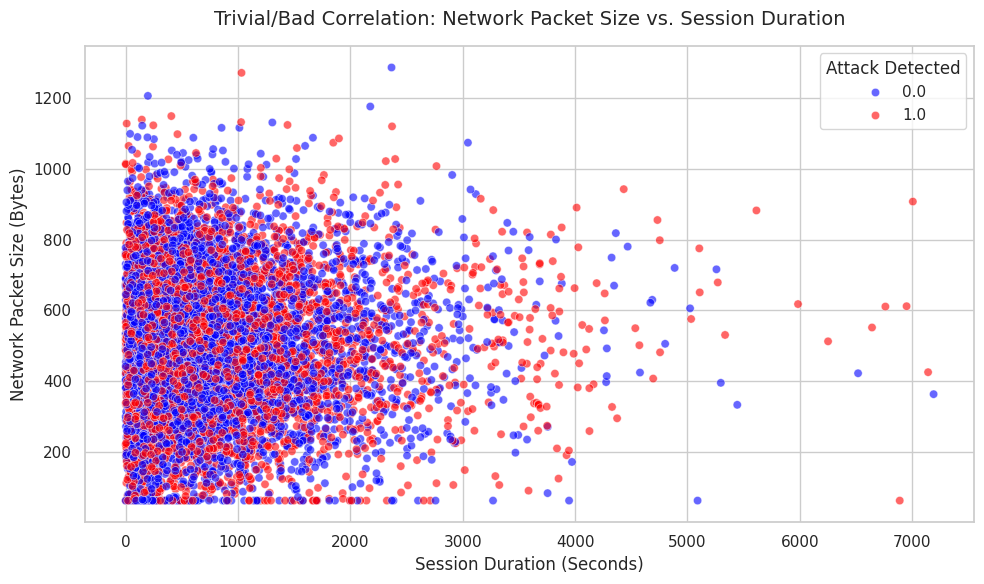

# **Scatter Plot with Positive Correlation - Step 6.3 - Part 2**

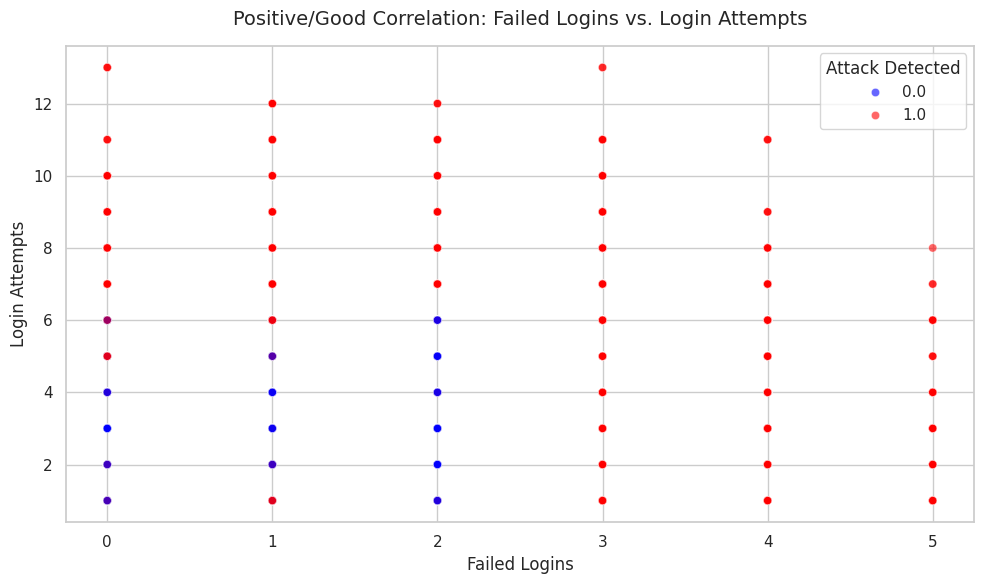